# Handwritten Digit Classification using Machine Learning

This project focuses on building a machine learning model to classify handwritten digits using pixel-based image data.  
The dataset contains numerical pixel intensity values representing handwritten digits from 0 to 9.

The main objective of this project is to perform data preprocessing, exploratory data analysis, and machine learning model development to accurately predict the digit labels.  
Different preprocessing and evaluation techniques will be applied to improve model performance and analyze the dataset effectively.

##### Importing Libraries

In this step, we import the libraries required for data analysis and machine learning.  

In [31]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier

%matplotlib inline
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print('All libraries loaded successfully.')

All libraries loaded successfully.


##### Loading the Dataset
We load the dataset into a pandas DataFrame so that we can inspect and analyze it in the following steps.

In [2]:
# Load the dataset
df = pd.read_csv("letters.csv")

##### Basic Dataset Inspection

In this step, we perform an initial inspection of the dataset to better understand its structure and contents.  
This includes checking the dataset shape, column names, data types, summary statistics, missing values, unique values, and duplicate records.

Basic inspection helps identify potential data quality issues and provides important insights before preprocessing and model building.

In [3]:
# Display the first 5 rows of the dataset
print("First 5 Rows of the Dataset:")
display(df.head())

First 5 Rows of the Dataset:


,label,pixel43,pixel44,pixel92,pixel124,pixel125,pixel126,pixel127,pixel128,pixel129,pixel130,pixel131,pixel132,pixel133,pixel134,pixel135,pixel136,pixel137,pixel138,pixel146,pixel147,pixel148,pixel149,pixel150,pixel151,pixel152,pixel153,pixel154,pixel155,pixel156,pixel157,pixel158,pixel159,pixel160,pixel327,pixel328,pixel329,pixel351,pixel410,pixel411,pixel412,pixel413,pixel414,pixel415,pixel416,pixel417
0,1,0,0,0,0,0,0,0,0,0,0,0,188,255,94,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,191,250,0,0,0,254,0,0,0,0,0,0,0,0
1,0,0,0,0,137,137,192,86,72,1,0,0,0,0,0,0,0,0,0,0,0,13,86,250,254,254,254,254,217,246,151,32,0,0,254,254,254,0,0,75,254,254,254,17,0,0
2,1,0,0,0,3,141,139,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9,254,254,8,0,0,0,0,0,0,0,0,184,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,220,179,6,0,0,0,0,0,0,0,0,9,77,0,0,142,0,0,0,94,255,69,0,0,0,0,0
4,0,0,0,0,155,254,254,254,157,30,2,0,0,0,0,0,0,0,0,0,0,8,103,253,253,253,253,253,253,253,253,114,2,0,253,253,253,0,0,0,223,253,253,253,129,0


In [4]:
# Display the shape of the dataset
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(42000, 46)


In [5]:
# Display column names
print("Column Names:")
print(df.columns)

Column Names:
Index(['label', 'pixel43', 'pixel44', 'pixel92', 'pixel124', 'pixel125',
       'pixel126', 'pixel127', 'pixel128', 'pixel129', 'pixel130', 'pixel131',
       'pixel132', 'pixel133', 'pixel134', 'pixel135', 'pixel136', 'pixel137',
       'pixel138', 'pixel146', 'pixel147', 'pixel148', 'pixel149', 'pixel150',
       'pixel151', 'pixel152', 'pixel153', 'pixel154', 'pixel155', 'pixel156',
       'pixel157', 'pixel158', 'pixel159', 'pixel160', 'pixel327', 'pixel328',
       'pixel329', 'pixel351', 'pixel410', 'pixel411', 'pixel412', 'pixel413',
       'pixel414', 'pixel415', 'pixel416', 'pixel417'],
      dtype='object')


In [6]:
# Display basic information about the dataset
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Data columns (total 46 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   label     42000 non-null  int64
 1   pixel43   42000 non-null  int64
 2   pixel44   42000 non-null  int64
 3   pixel92   42000 non-null  int64
 4   pixel124  42000 non-null  int64
 5   pixel125  42000 non-null  int64
 6   pixel126  42000 non-null  int64
 7   pixel127  42000 non-null  int64
 8   pixel128  42000 non-null  int64
 9   pixel129  42000 non-null  int64
 10  pixel130  42000 non-null  int64
 11  pixel131  42000 non-null  int64
 12  pixel132  42000 non-null  int64
 13  pixel133  42000 non-null  int64
 14  pixel134  42000 non-null  int64
 15  pixel135  42000 non-null  int64
 16  pixel136  42000 non-null  int64
 17  pixel137  42000 non-null  int64
 18  pixel138  42000 non-null  int64
 19  pixel146  42000 non-null  int64
 20  pixel147  42000 non-null  int64
 21  pixel148  4200

In [7]:
# Summary statistics
df.describe()

,label,pixel43,pixel44,pixel92,pixel124,pixel125,pixel126,pixel127,pixel128,pixel129,pixel130,pixel131,pixel132,pixel133,pixel134,pixel135,pixel136,pixel137,pixel138,pixel146,pixel147,pixel148,pixel149,pixel150,pixel151,pixel152,pixel153,pixel154,pixel155,pixel156,pixel157,pixel158,pixel159,pixel160,pixel327,pixel328,pixel329,pixel351,pixel410,pixel411,pixel412,pixel413,pixel414,pixel415,pixel416,pixel417
count,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000
mean,4.456643,0.171357,0.164476,1.192833,28.043952,36.084976,42.713952,46.092310,44.542452,38.948524,30.964762,22.909548,14.868857,8.691619,4.550786,2.099881,0.838762,0.202762,0.035476,3.557690,7.149929,12.928143,21.419881,32.221857,45.363500,60.175929,75.010571,86.296405,91.588143,89.450286,80.302595,65.761976,49.647786,34.390500,88.699262,64.587571,42.461048,102.124119,107.683952,79.750548,56.31481,39.244643,25.754262,14.858619,5.844476,0.829643
std,2.887730,5.726352,5.515774,14.692403,70.505431,78.631145,84.390533,87.287033,85.740313,81.223946,73.631465,64.391170,52.365152,40.089466,28.811324,19.634788,12.019612,5.462245,2.335536,25.518983,36.402328,48.951568,62.484604,75.183031,86.645879,96.333439,103.488456,107.473450,108.790348,108.040910,105.144387,98.845901,89.476442,76.850579,107.822933,98.869820,85.090524,110.961953,111.360981,104.287852,94.20847,82.799118,69.597297,54.018163,33.293343,11.818307
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,39.000000,60.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,29.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.000000,114.000000,175.000000,213.000000,225.000000,220.000000,194.000000,138.000000,51.000000,0.000000,222.000000,131.000000,10.000000,247.000000,250.000000,191.000000,86.00000,0.000000,0.000000,0.000000,0.000000,0.000000
max,9.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,254.000000,230.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255

In [8]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
print(
    pd.DataFrame(
        {
            "Missing Count": missing, 
            "Missing %": missing_pct
        }
    ).sort_values(by="Missing %", ascending=False))

          Missing Count  Missing %
label                 0        0.0
pixel327              0        0.0
pixel152              0        0.0
pixel153              0        0.0
pixel154              0        0.0
pixel155              0        0.0
pixel156              0        0.0
pixel157              0        0.0
pixel158              0        0.0
pixel159              0        0.0
pixel160              0        0.0
pixel328              0        0.0
pixel43               0        0.0
pixel329              0        0.0
pixel351              0        0.0
pixel410              0        0.0
pixel411              0        0.0
pixel412              0        0.0
pixel413              0        0.0
pixel414              0        0.0
pixel415              0        0.0
pixel416              0        0.0
pixel151              0        0.0
pixel150              0        0.0
pixel149              0        0.0
pixel148              0        0.0
pixel44               0        0.0
pixel92             

In [9]:
# Unique values per column
df.nunique()

label        10
pixel43      47
pixel44      46
pixel92     183
pixel124    256
pixel125    256
pixel126    256
pixel127    256
pixel128    256
pixel129    256
pixel130    256
pixel131    256
pixel132    256
pixel133    254
pixel134    253
pixel135    225
pixel136    157
pixel137     73
pixel138     15
pixel146    242
pixel147    255
pixel148    256
pixel149    256
pixel150    256
pixel151    256
pixel152    256
pixel153    256
pixel154    256
pixel155    256
pixel156    256
pixel157    256
pixel158    256
pixel159    256
pixel160    256
pixel327    256
pixel328    256
pixel329    256
pixel351    256
pixel410    256
pixel411    256
pixel412    256
pixel413    256
pixel414    256
pixel415    256
pixel416    240
pixel417    163
dtype: int64

In [12]:
# Duplicate rows
print(df.duplicated().sum())

1633


##### Data Cleaning

Before building machine learning models, it is important to clean the dataset.  
In this step, we remove the duplicate records to improve data quality and avoid biased model performance.

The earlier inspection showed that the dataset contains duplicate rows, so we will remove them and verify the updated dataset shape.

In [13]:
# Remove duplicate rows
df = df.drop_duplicates()

# Reset index after removing duplicates
df = df.reset_index(drop=True)

In [14]:
# Verify Updated Dataset
print("\nDataset Shape After Removing Duplicates:")
print(df.shape)

print("\nDuplicate Rows Remaining:")
print(df.duplicated().sum())


Dataset Shape After Removing Duplicates:
(40367, 46)

Duplicate Rows Remaining:
0


##### Feature and Target Separation

In machine learning, the dataset is divided into input features and the target variable.  
The feature variables are used by the model to learn patterns, while the target variable contains the actual class labels to be predicted.

In this dataset:
- The `label` column represents the target variable (digit classes from 0 to 9).
- All remaining pixel columns are used as input features.

In [15]:
# Separate features and target variable

# Input features
X = df.drop("label", axis=1)

# Target variable
y = df["label"]

In [16]:
# Display shapes
print("Feature Matrix Shape:")
print(X.shape)

print("\nTarget Variable Shape:")
print(y.shape)

Feature Matrix Shape:
(40367, 45)

Target Variable Shape:
(40367,)


In [17]:
# Display sample data
print("\nFirst 5 Rows of Features:")
display(X.head())

print("\nFirst 5 Values of Target Variable:")
display(y.head())


First 5 Rows of Features:


,pixel43,pixel44,pixel92,pixel124,pixel125,pixel126,pixel127,pixel128,pixel129,pixel130,pixel131,pixel132,pixel133,pixel134,pixel135,pixel136,pixel137,pixel138,pixel146,pixel147,pixel148,pixel149,pixel150,pixel151,pixel152,pixel153,pixel154,pixel155,pixel156,pixel157,pixel158,pixel159,pixel160,pixel327,pixel328,pixel329,pixel351,pixel410,pixel411,pixel412,pixel413,pixel414,pixel415,pixel416,pixel417
0,0,0,0,0,0,0,0,0,0,0,0,188,255,94,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,191,250,0,0,0,254,0,0,0,0,0,0,0,0
1,0,0,0,137,137,192,86,72,1,0,0,0,0,0,0,0,0,0,0,0,13,86,250,254,254,254,254,217,246,151,32,0,0,254,254,254,0,0,75,254,254,254,17,0,0
2,0,0,0,3,141,139,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9,254,254,8,0,0,0,0,0,0,0,0,184,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,220,179,6,0,0,0,0,0,0,0,0,9,77,0,0,142,0,0,0,94,255,69,0,0,0,0,0
4,0,0,0,155,254,254,254,157,30,2,0,0,0,0,0,0,0,0,0,0,8,103,253,253,253,253,253,253,253,253,114,2,0,253,253,253,0,0,0,223,253,253,253,129,0



First 5 Values of Target Variable:


0    1
1    0
2    1
3    4
4    0
Name: label, dtype: int64

##### Class Distribution Analysis

Before training a machine learning model, it is important to examine the distribution of the target classes.  
This helps determine whether the dataset is balanced or imbalanced.

A balanced dataset improves model learning and helps prevent bias toward specific classes.

In [18]:
# Check class distribution

# Count the occurrences of each class label
class_counts = y.value_counts().sort_index()

print("Class Distribution:")
print(class_counts)

Class Distribution:
label
0    4132
1    4636
2    4139
3    4282
4    4037
5    3131
6    4137
7    3980
8    4049
9    3844
Name: count, dtype: int64


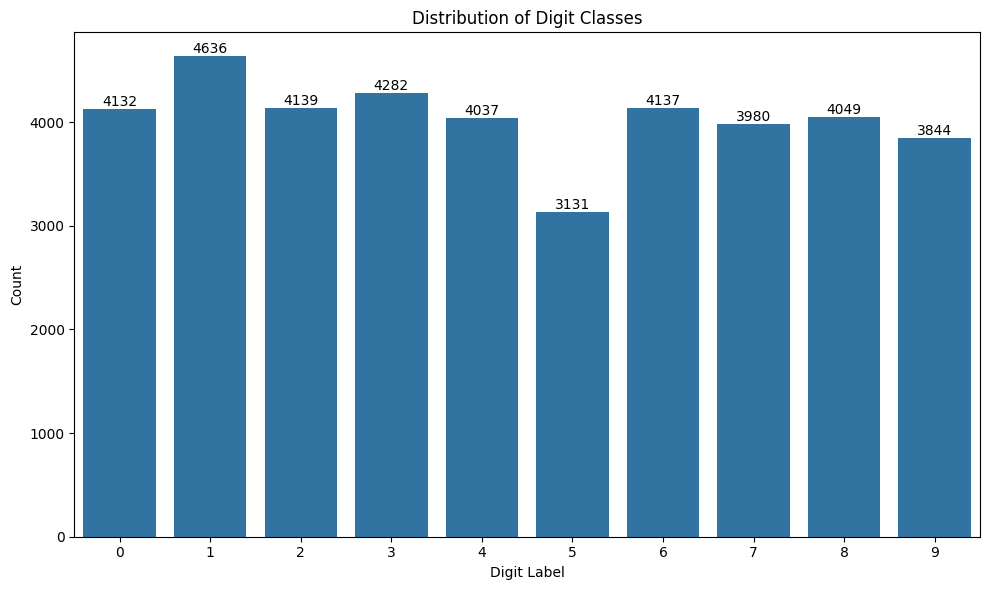

In [36]:
# Visualize Class Distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=y)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Digit Classes")
plt.xlabel("Digit Label")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

##### Feature Scaling

Feature scaling is an important preprocessing step in machine learning.  
The pixel values in this dataset range from 0 to 255, and scaling helps bring all feature values to a similar range.

In this step, we normalize the pixel values by dividing them by 255 so that all values fall between 0 and 1.  
This improves model performance and helps algorithms learn more efficiently.

In [21]:
# Normalize Feature Values

# Scale pixel values to the range 0-1
X = X / 255.0

In [22]:
# Verify Scaled Data
print("First 5 Rows After Feature Scaling:")
display(X.head())

First 5 Rows After Feature Scaling:


,pixel43,pixel44,pixel92,pixel124,pixel125,pixel126,pixel127,pixel128,pixel129,pixel130,pixel131,pixel132,pixel133,pixel134,pixel135,pixel136,pixel137,pixel138,pixel146,pixel147,pixel148,pixel149,pixel150,pixel151,pixel152,pixel153,pixel154,pixel155,pixel156,pixel157,pixel158,pixel159,pixel160,pixel327,pixel328,pixel329,pixel351,pixel410,pixel411,pixel412,pixel413,pixel414,pixel415,pixel416,pixel417
0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.737255,1.0,0.368627,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.749020,0.980392,0.000000,0.000000,0.000000,0.996078,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,0.0,0.0,0.0,0.537255,0.537255,0.752941,0.337255,0.282353,0.003922,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.050980,0.337255,0.980392,0.996078,0.996078,0.996078,0.996078,0.850980,0.964706,0.592157,0.125490,0.000000,0.000000,0.996078,0.996078,0.996078,0.000000,0.000000,0.294118,0.996078,0.996078,0.996078,0.066667,0.000000,0.0
2,0.0,0.0,0.0,0.011765,0.552941,0.545098,0.011765,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.035294,0.996078,0.996078,0.031373,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.721569,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.862745,0.701961,0.023529,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.035294,0.301961,0.000000,0.000000,0.556863,0.000000,0.000000,0.000000,0.368627,1.000000,0.270588,0.000000,0.000000,0.000000,0.000000,0.0
4,0.0,0.0,0.0,0.607843,0.996078,0.996078,0.996078,0.615686,0.117647,0.007843,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.031373,0.403922,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.447059,0.007843,0.000000,0.992157,0.992157,0.992157,0.000000,0.000000,0.000000,0.874510,0.992157,0.992157,0.992157,0.505882,0.0


In [23]:
# Check Minimum and Maximum Values
print("Minimum Feature Value:", X.min().min())
print("Maximum Feature Value:", X.max().max())

Minimum Feature Value: 0.0
Maximum Feature Value: 1.0


##### Train-Test Split

To evaluate the machine learning model properly, the dataset is divided into training data and testing data.

- The training set is used to train the model.
- The testing set is used to evaluate how well the model performs on unseen data.

In this step, we split the dataset into:

- 80% training data
- 20% testing data

We also use `random_state` to ensure reproducible results.

In [25]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display shapes of the split datasets
print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)

print("\nTraining Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Feature Shape: (32293, 45)
Testing Feature Shape: (8074, 45)

Training Target Shape: (32293,)
Testing Target Shape: (8074,)


##### Model Building - K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification problems.
The algorithm predicts the class of a data point based on the labels of its nearest neighboring data points.

In this step, we:

- Train a KNN classifier using the training dataset.
- Predict digit labels for the testing dataset.
- Evaluate model performance using accuracy score and classification metrics.

In [27]:
# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions on the test dataset
y_pred_knn = knn_model.predict(X_test)

# Calculate model accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Model Accuracy:")
print(round(knn_accuracy * 100, 2), "%")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Model Accuracy:
65.02 %

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       826
           1       0.77      0.96      0.86       927
           2       0.63      0.63      0.63       828
           3       0.56      0.58      0.57       857
           4       0.64      0.53      0.58       807
           5       0.60      0.48      0.53       626
           6       0.86      0.88      0.87       828
           7       0.45      0.61      0.52       796
           8       0.62      0.47      0.54       810
           9       0.47      0.38      0.42       769

    accuracy                           0.65      8074
   macro avg       0.64      0.64      0.64      8074
weighted avg       0.65      0.65      0.64      8074



##### KNN Confusion Matrix Visualization

A confusion matrix helps evaluate the classification performance of the KNN model.
It shows the number of correct and incorrect predictions made for each digit class.

The diagonal values represent correct predictions, while the off-diagonal values represent misclassifications.

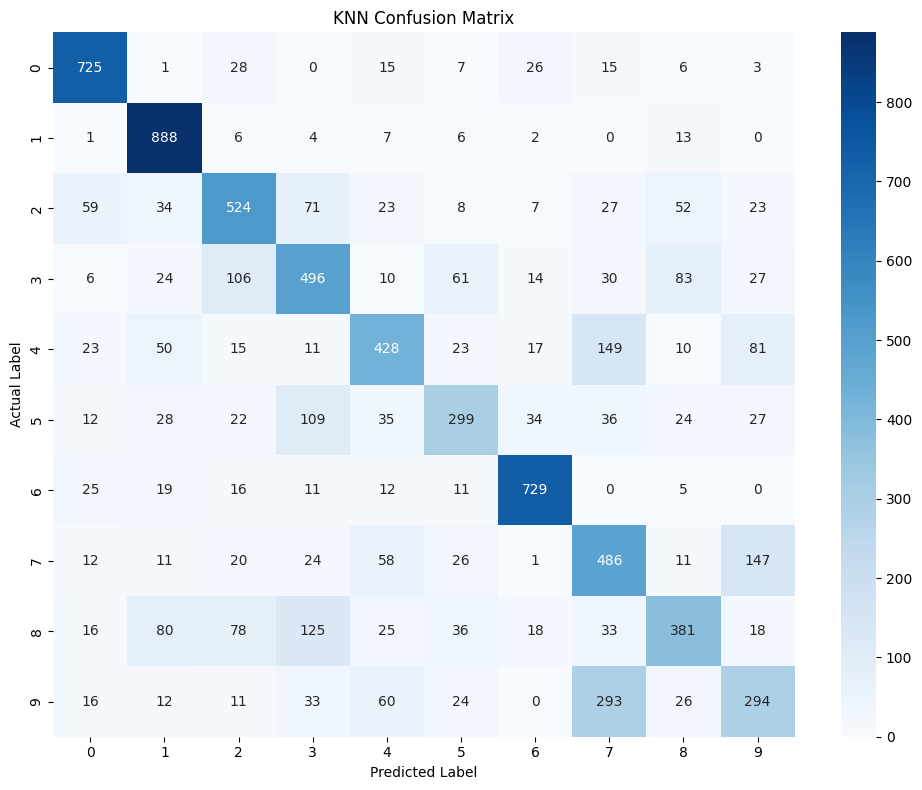

In [28]:
# Generate confusion matrix
knn_cm = confusion_matrix(y_test, y_pred_knn)

# Plot confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

##### Model Building - Neural Network

Neural Networks are advanced machine learning models designed to recognize complex patterns in data.
They are especially effective for image classification tasks such as handwritten digit recognition.

In this step, we:

- Build a Multi-Layer Perceptron (MLP) Neural Network model.
- Train the model using the training dataset.
- Predict digit labels for the testing dataset.
- Evaluate model performance using accuracy score and classification metrics.

In [32]:
# Create Neural Network model
nn_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# Train the Neural Network model
nn_model.fit(X_train, y_train)

# Make predictions on the test dataset
y_pred_nn = nn_model.predict(X_test)

# Calculate model accuracy
nn_accuracy = accuracy_score(y_test, y_pred_nn)

print("Neural Network Model Accuracy:")
print(round(nn_accuracy * 100, 2), "%")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))

Neural Network Model Accuracy:
70.14 %

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       826
           1       0.87      0.94      0.91       927
           2       0.72      0.66      0.69       828
           3       0.67      0.57      0.61       857
           4       0.77      0.57      0.66       807
           5       0.63      0.58      0.60       626
           6       0.90      0.91      0.91       828
           7       0.50      0.72      0.59       796
           8       0.60      0.63      0.62       810
           9       0.49      0.48      0.48       769

    accuracy                           0.70      8074
   macro avg       0.70      0.69      0.69      8074
weighted avg       0.71      0.70      0.70      8074



##### Neural Network Confusion Matrix Visualization

A confusion matrix helps visualize the performance of the Neural Network model by comparing actual digit labels with predicted labels.

Higher values along the diagonal indicate correct classifications, while off-diagonal values represent prediction errors between digit classes.

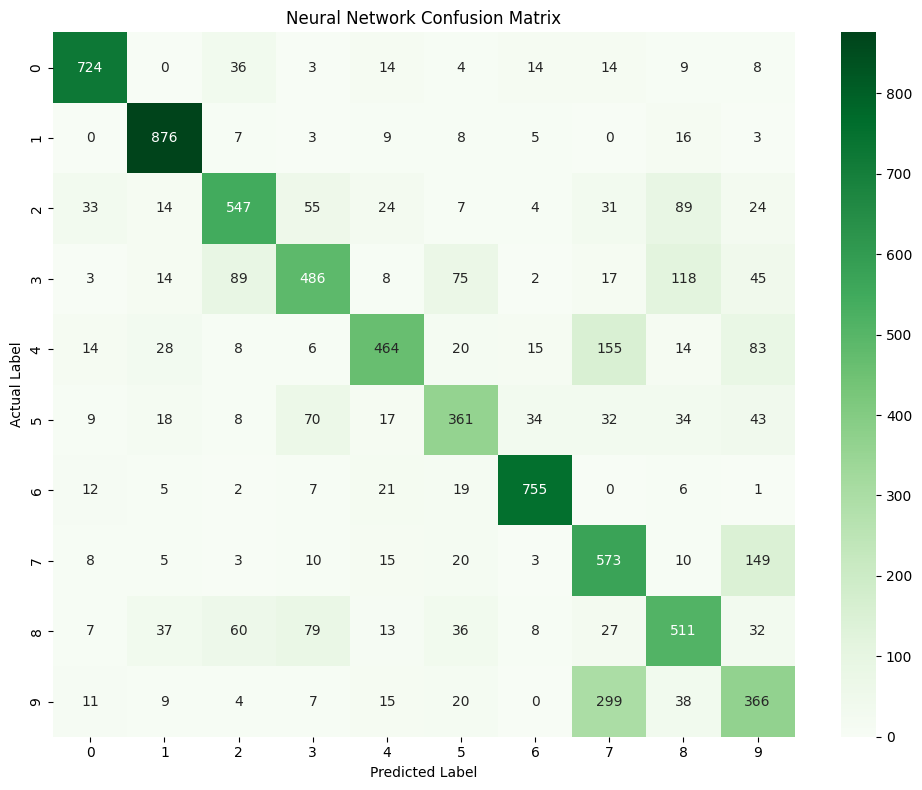

In [33]:
# Generate confusion matrix for Neural Network model
nn_cm = confusion_matrix(y_test, y_pred_nn)

# Plot confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    nn_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

##### Model Performance Comparison

To compare the effectiveness of the KNN model and the Neural Network model, we evaluate both models using benchmarking metrics.

The comparison includes:

- Accuracy Score
- Precision
- Recall
- F1-Score

These metrics help determine which model performs better for handwritten digit classification.

In [34]:
# Create comparison table for model evaluation

comparison_df = pd.DataFrame({
    "Model": ["KNN", "Neural Network"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nn)
    ],
    
    "Precision": [
        classification_report(y_test, y_pred_knn, output_dict=True)["weighted avg"]["precision"],
        classification_report(y_test, y_pred_nn, output_dict=True)["weighted avg"]["precision"]
    ],
    
    "Recall": [
        classification_report(y_test, y_pred_knn, output_dict=True)["weighted avg"]["recall"],
        classification_report(y_test, y_pred_nn, output_dict=True)["weighted avg"]["recall"]
    ],
    
    "F1-Score": [
        classification_report(y_test, y_pred_knn, output_dict=True)["weighted avg"]["f1-score"],
        classification_report(y_test, y_pred_nn, output_dict=True)["weighted avg"]["f1-score"]
    ]
})

# Round values for better readability
comparison_df = comparison_df.round(4)

# Display comparison table
print("Model Performance Comparison:")
display(comparison_df)

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.6502,0.6469,0.6502,0.6436
1,Neural Network,0.7014,0.7094,0.7014,0.7011


##### Model Performance Comparison Visualization

Visualizing model performance metrics makes it easier to compare the strengths and weaknesses of both models.

In this step, we create bar charts to compare:

- Accuracy
- Precision
- Recall
- F1-Score

for the KNN and Neural Network models.

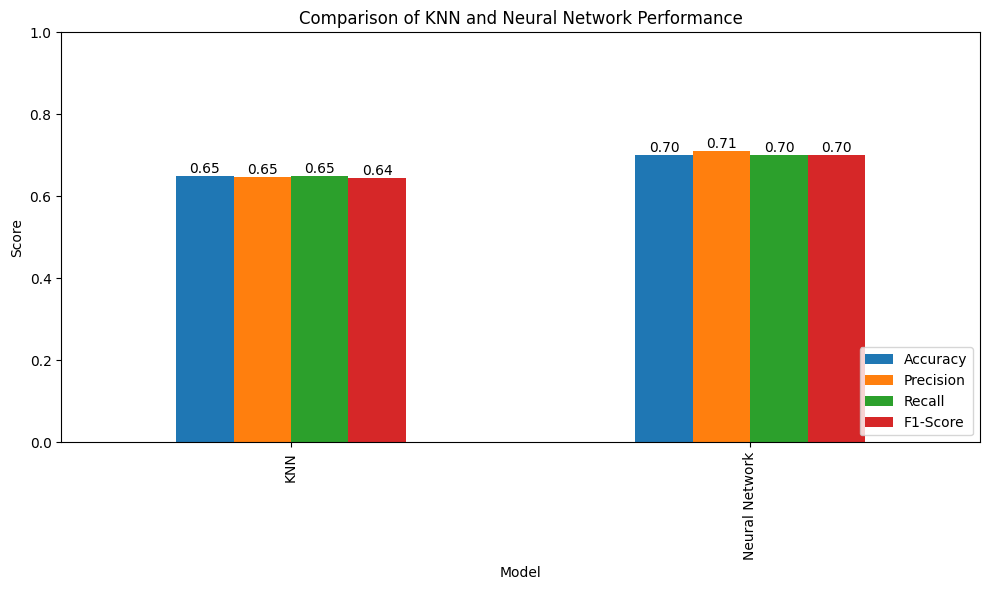

In [39]:
# Set model names as index
comparison_plot = comparison_df.set_index("Model")

# Plot comparison chart
ax = comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
# Customize plot
plt.title("Comparison of KNN and Neural Network Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)

plt.legend(loc="lower right")

plt.tight_layout()
plt.show()